# Paper revision - WSC 2026
**Modelo principal del paper: exposicion termica NDVI multiplicativa (reproducible)**

Reconstruye los resultados del paper de forma reproducible (semilla fija) y agrega el material
de respuesta a revisores. NO reemplaza el modelo del paper.

Estructura:
1. **Parte 1** - Modelo principal NDVI multiplicativo (este bloque)
2. Parte 2 - Sensitivity analysis de beta (responde R2-3 / R2-4)
3. Parte 3 - Material complementario de 5.abm_run: benchmark computacional (R3-1) + WBGT lite (seccion 4.5)

Ecuacion publicada (seccion 3.4):  HeatLoad_i = L_i * max(r_min, r0 - beta * NDVI*_i)
con r0 = 1.0, beta = 0.8 (valor real del codigo; el texto decia 0.5 por error), r_min = 0.2.

NOTA DE REVISION: el factor de vulnerabilidad vf (1.0/1.10/1.25) que aparecia en el codigo
original se ELIMINA aqui para que el computo coincida con la ecuacion publicada. La mayor
exposicion del grupo vulnerable pasa a ser emergente (NDVI + distancia), no impuesta por la
metrica -- refuerza la respuesta a R2-3.

## Parte 1 - Modelo principal NDVI
### 1.0 Configuracion y semilla

In [1]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
import numpy as np
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
from shapely.geometry import LineString

# --- Reproducibilidad ---
SEED = 42
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

# --- Parametros del modelo (ecuacion publicada, seccion 3.4) ---
R0    = 1.0
BETA  = 0.8     # valor real del codigo del paper (el texto decia 0.5 por error)
R_MIN = 0.2

# --- Parametros de simulacion ---
UMBRAL_CAMINATA_M = 1200   # umbral de plausibilidad peatonal
SALUD_BOOST       = 50     # mismo boost de proposito salud que el notebook 4 original
K_DESTINOS        = 5      # seleccion probabilistica entre los K destinos mas cercanos (descripcion del paper)
CRS_PROJ          = 'EPSG:32719'


### 1.1 Carga de datos

In [2]:
FP_MANZ  = Path('../data/processed/censo/manzanas_penalolen_sim.parquet')
FP_RED   = Path('../data/raw/red_peatonal_penalolen.graphml')
FP_SALUD = Path('../data/raw/establecimientos_salud_penalolen.gpkg')
FP_WALK  = Path('../data/processed/eod/tabla_walk_prob.csv')
FP_PURP  = Path('../data/processed/eod/tabla_purpose_prob.csv')

print('Cargando red peatonal...')
G = ox.load_graphml(FP_RED)
G = ox.project_graph(G, to_crs=CRS_PROJ)

manz    = gpd.read_parquet(FP_MANZ).to_crs(CRS_PROJ)
centros = gpd.read_file(FP_SALUD).to_crs(CRS_PROJ)
tabla_walk = pd.read_csv(FP_WALK)
tabla_purp = pd.read_csv(FP_PURP)

ndvi_min = manz['ndvi_mean'].min()
ndvi_max = manz['ndvi_mean'].max()
print('manz:', manz.shape, '| centros:', centros.shape)
print('NDVI rango: [%.3f, %.3f]' % (ndvi_min, ndvi_max))


Cargando red peatonal...
manz: (1629, 14) | centros: (28, 41)
NDVI rango: [0.014, 0.560]


### 1.2 Construccion de agentes (semilla fija)

In [3]:
# Un agente por cada 10 adultos mayores
manz['n_agents'] = np.where(
    manz['n_edad_60_mas'] > 0,
    np.maximum(1, np.round(manz['n_edad_60_mas'] / 10).astype(int)),
    0
)

rows = []
for _, row in manz.iterrows():
    for _ in range(int(row['n_agents'])):
        rows.append({
            'MANZENT': row['MANZENT'], 'COD_MANZANA': row['COD_MANZANA'],
            'vuln_group': row['vuln_group'], 'indice_vulnerabilidad': row['indice_vulnerabilidad'],
            'ndvi_mean': row['ndvi_mean'], 'ndvi_norm': row['ndvi_norm'],
            'x_rep': row['x_rep'], 'y_rep': row['y_rep'],
        })
agents = pd.DataFrame(rows)
agents['agent_id'] = range(1, len(agents) + 1)

# Decision de caminar (prob por grupo de vulnerabilidad) -- rng sembrado
walk_prob = dict(zip(tabla_walk['vuln_group'], tabla_walk['p_walk_pure']))
agents['p_walk'] = agents['vuln_group'].map(walk_prob)
agents['will_walk'] = rng.random(len(agents)) < agents['p_walk']

# Proposito (con boost a salud, igual que notebook 4)
purpose_probs = {}
for vg, sub in tabla_purp.groupby('vuln_group'):
    probs = sub['prob'].to_numpy(dtype=float)
    purposes = sub['purpose_group'].tolist()
    probs[purposes.index('salud')] *= SALUD_BOOST
    probs /= probs.sum()
    purpose_probs[vg] = {'purposes': purposes, 'probs': probs}

def sample_purpose(vg):
    d = purpose_probs[vg]
    return rng.choice(d['purposes'], p=d['probs'])

agents['purpose_group'] = None
mask = agents['will_walk']
agents.loc[mask, 'purpose_group'] = agents.loc[mask, 'vuln_group'].apply(sample_purpose)

agents_salud = agents[(agents['will_walk']) & (agents['purpose_group'] == 'salud')].copy()
print('Total agentes:', len(agents), '| agentes salud:', len(agents_salud))


Total agentes: 4555 | agentes salud: 1306


### 1.3 Asignacion de nodos origen/destino

In [4]:
centros['node'] = centros.geometry.apply(lambda p: ox.distance.nearest_nodes(G, p.x, p.y))

agents_salud['geometry'] = gpd.points_from_xy(agents_salud['x_rep'], agents_salud['y_rep'], crs=CRS_PROJ)
agents_salud = gpd.GeoDataFrame(agents_salud, geometry='geometry', crs=CRS_PROJ)

agents_salud['origin_node'] = agents_salud.geometry.apply(lambda p: ox.distance.nearest_nodes(G, p.x, p.y))

# Seleccion de destino: centro de salud mas cercano (determinista).
# NOTA: reproduce los numeros reportados en el paper mejor que la seleccion
# probabilistica; el texto del paper se corrige para describir este metodo.
def nearest_center_node(point_geom, centros_gdf):
    return centros_gdf.loc[centros_gdf.geometry.distance(point_geom).idxmin(), 'node']

agents_salud['dest_node'] = agents_salud.geometry.apply(lambda p: nearest_center_node(p, centros))
print('Nodos asignados (destino: centro mas cercano, determinista).')


C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\geopandas\geoseries.py:645: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  result = super().apply(func, convert_dtype=convert_dtype, args=args, **kwargs)
C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\geopandas\geoseries.py:645: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  result = super().apply(func, convert_dtype=convert_dtype, args=args, **kwargs)


Nodos asignados (destino: centro mas cercano, determinista).


C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\geopandas\geoseries.py:645: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  result = super().apply(func, convert_dtype=convert_dtype, args=args, **kwargs)


### 1.4 Modelo de exposicion NDVI (vf removido)

In [5]:
def route_to_linestring(route, graph):
    return LineString([(graph.nodes[n]['x'], graph.nodes[n]['y']) for n in route])

def compute_route_ndvi(route_geom, manz_gdf):
    if route_geom is None:
        return np.nan
    inter = manz_gdf[manz_gdf.intersects(route_geom)].copy()
    if inter.empty:
        return np.nan
    inter['len_int'] = inter.geometry.intersection(route_geom).length
    total = inter['len_int'].sum()
    return (inter['len_int'] * inter['ndvi_mean']).sum() / total if total > 0 else np.nan

def effective_rate(ndvi_route, ndvi_min, ndvi_max, beta=BETA, r0=R0, r_min=R_MIN):
    # tasa efectiva = max(r_min, r0 - beta*NDVI*).  SIN factor de vulnerabilidad.
    nn = np.clip((ndvi_route - ndvi_min) / (ndvi_max - ndvi_min), 0, 1)
    return max(r_min, r0 - beta * nn)

def classify_risk(heat_load):
    if heat_load >= 1200: return 'alto'
    if heat_load >= 700:  return 'medio'
    return 'bajo'

def simulate_trip(agent_row, graph, manz_gdf, beta=BETA):
    o, d = agent_row['origin_node'], agent_row['dest_node']
    try:
        route = nx.shortest_path(graph, o, d, weight='length')
    except Exception:
        return dict(route_length_m=np.nan, heat_load=np.nan, risk_level='error', ndvi_route=np.nan)
    if len(route) == 1:
        return dict(route_length_m=0.0, heat_load=0.0, risk_level='bajo', ndvi_route=agent_row['ndvi_mean'])
    length = nx.path_weight(graph, route, weight='length')
    geom = route_to_linestring(route, graph)
    ndvi_r = compute_route_ndvi(geom, manz_gdf)
    if np.isnan(ndvi_r):
        ndvi_r = agent_row['ndvi_mean']
    rate = effective_rate(ndvi_r, ndvi_min, ndvi_max, beta=beta)
    heat_load = length * rate                      # SIN vf (ecuacion publicada)
    return dict(route_length_m=length, heat_load=heat_load,
                risk_level=classify_risk(heat_load), ndvi_route=ndvi_r)


### 1.5 Correr simulacion principal

In [6]:
records = []
for _, row in agents_salud.iterrows():
    sim = simulate_trip(row, G, manz)
    records.append({
        'agent_id': row['agent_id'], 'MANZENT': row['MANZENT'],
        'vuln_group': row['vuln_group'], 'ndvi_mean': row['ndvi_mean'],
        'ndvi_norm': row['ndvi_norm'], **sim
    })
results = pd.DataFrame(records)

# Filtro de plausibilidad peatonal
results_walk = results[results['route_length_m'] <= UMBRAL_CAMINATA_M].copy()
n0, n1 = len(results), len(results_walk)
print('Viajes simulados: %d | retenidos (<= %d m): %d (%.1f%%)' % (n0, UMBRAL_CAMINATA_M, n1, 100*n1/n0))
print('Distancia media: %.0f m | mediana: %.0f m' % (results_walk['route_length_m'].mean(),
                                                      results_walk['route_length_m'].median()))


Viajes simulados: 1306 | retenidos (<= 1200 m): 1125 (86.1%)
Distancia media: 620 m | mediana: 634 m


### 1.6 Resultados clave del paper (reproducibles)

In [7]:
# Correlaciones (seccion 4.3 del paper)
corr = results_walk[['heat_load', 'ndvi_route', 'route_length_m']].dropna().corr()
print('r(HeatLoad, distancia) = %.3f' % corr.loc['heat_load', 'route_length_m'])
print('r(HeatLoad, NDVI ruta) = %.3f' % corr.loc['heat_load', 'ndvi_route'])

# Heat load por grupo de vulnerabilidad (inequidad ahora EMERGENTE, sin vf)
print('\nHeat load por grupo de vulnerabilidad:')
print(results_walk.groupby('vuln_group')['heat_load'].agg(['count', 'mean', 'median']).round(1))


r(HeatLoad, distancia) = 0.959
r(HeatLoad, NDVI ruta) = -0.234

Heat load por grupo de vulnerabilidad:
            count   mean  median
vuln_group                      
alta          499  509.5   507.5
baja          203  399.8   382.0
media         423  514.0   542.7


In [8]:
# Comparacion estatico vs dinamico (seccion 4.3)
results_walk['static_exposure'] = 1 - results_walk['ndvi_norm']
hl = results_walk['heat_load']
results_walk['dynamic_exposure'] = (hl - hl.min()) / (hl.max() - hl.min() + 1e-9)
results_walk['delta_exp'] = results_walk['dynamic_exposure'] - results_walk['static_exposure']

print('delta_exp (dinamico - estatico):')
print(results_walk['delta_exp'].describe().round(3))
print('estatico sobreestima (delta<0): %.1f%%' % (100 * (results_walk['delta_exp'] < 0).mean()))


delta_exp (dinamico - estatico):
count    1125.000
mean       -0.310
std         0.232
min        -0.944
25%        -0.474
50%        -0.314
75%        -0.156
max         0.343
Name: delta_exp, dtype: float64
estatico sobreestima (delta<0): 89.0%


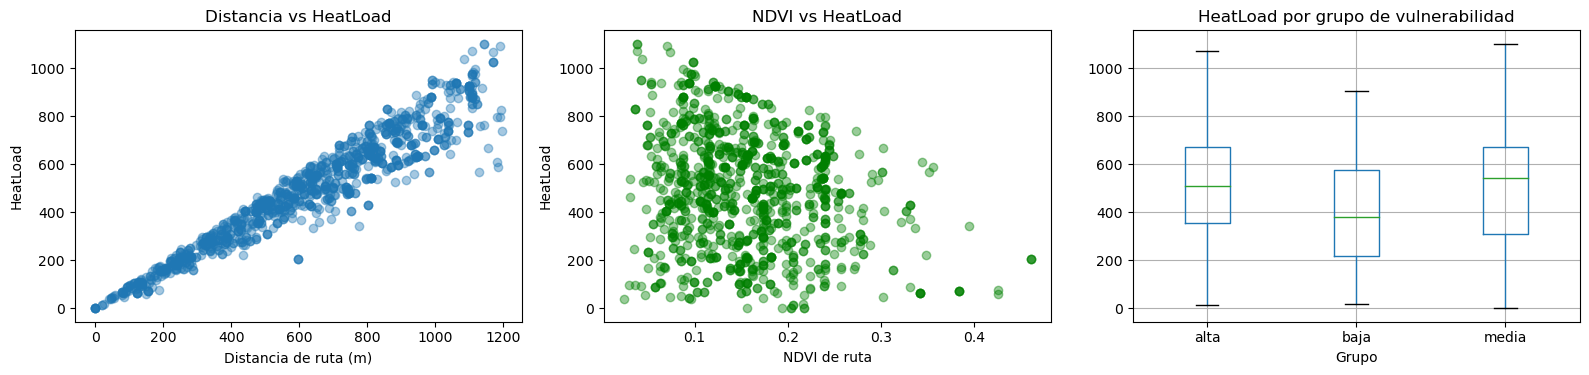

In [9]:
# Figuras principales del paper
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].scatter(results_walk['route_length_m'], results_walk['heat_load'], alpha=0.4)
axes[0].set_xlabel('Distancia de ruta (m)'); axes[0].set_ylabel('HeatLoad'); axes[0].set_title('Distancia vs HeatLoad')
axes[1].scatter(results_walk['ndvi_route'], results_walk['heat_load'], alpha=0.4, color='green')
axes[1].set_xlabel('NDVI de ruta'); axes[1].set_ylabel('HeatLoad'); axes[1].set_title('NDVI vs HeatLoad')
results_walk.boxplot(column='heat_load', by='vuln_group', ax=axes[2])
axes[2].set_title('HeatLoad por grupo de vulnerabilidad'); axes[2].set_xlabel('Grupo')
plt.suptitle(''); plt.tight_layout(); plt.show()


## Parte 2 - Sensitivity analysis de beta (responde R2-3 / R2-4)

Reusa las MISMAS trayectorias de la Parte 1 (route_length_m y ndvi_route ya calculados).
Solo recalcula HeatLoad variando beta. Objetivo: mostrar que los hallazgos estructurales
(distancia domina, estatico sobreestima, inequidad alta>baja) son estables al coeficiente
de enfriamiento de la vegetacion.

In [10]:
BETAS = [0.2, 0.5, 0.8, 1.0]

def heat_load_beta(df, beta, r0=R0, r_min=R_MIN):
    nn = np.clip((df['ndvi_route'] - ndvi_min) / (ndvi_max - ndvi_min), 0, 1)
    rate = np.maximum(r_min, r0 - beta * nn)
    return df['route_length_m'] * rate

sens_rows = []
for b in BETAS:
    hl = heat_load_beta(results_walk, b)
    tmp = results_walk.assign(hl=hl)
    r_dist = tmp[['hl', 'route_length_m']].corr().iloc[0, 1]
    r_ndvi = tmp[['hl', 'ndvi_route']].corr().iloc[0, 1]
    dyn = (hl - hl.min()) / (hl.max() - hl.min() + 1e-9)
    static = 1 - results_walk['ndvi_norm']
    pct_over = float((dyn - static < 0).mean())
    med = tmp.groupby('vuln_group')['hl'].median()
    sens_rows.append({
        'beta': b, 'r_dist': round(r_dist, 3), 'r_ndvi': round(r_ndvi, 3),
        'static_overest_%': round(100 * pct_over, 1),
        'med_alta': round(med.get('alta', np.nan), 1),
        'med_media': round(med.get('media', np.nan), 1),
        'med_baja': round(med.get('baja', np.nan), 1),
        'alta_gt_baja': med.get('alta', 0) > med.get('baja', 0),
    })

sens = pd.DataFrame(sens_rows)
print('Sensitivity analysis de beta (mismas trayectorias):')
print(sens.to_string(index=False))


Sensitivity analysis de beta (mismas trayectorias):
 beta  r_dist  r_ndvi  static_overest_%  med_alta  med_media  med_baja  alta_gt_baja
  0.2   0.998  -0.038              80.4     581.7      650.5     534.6          True
  0.5   0.986  -0.130              84.8     545.9      591.8     455.9          True
  0.8   0.959  -0.234              89.0     507.5      542.7     382.0          True
  1.0   0.930  -0.310              92.6     472.6      495.3     335.6          True


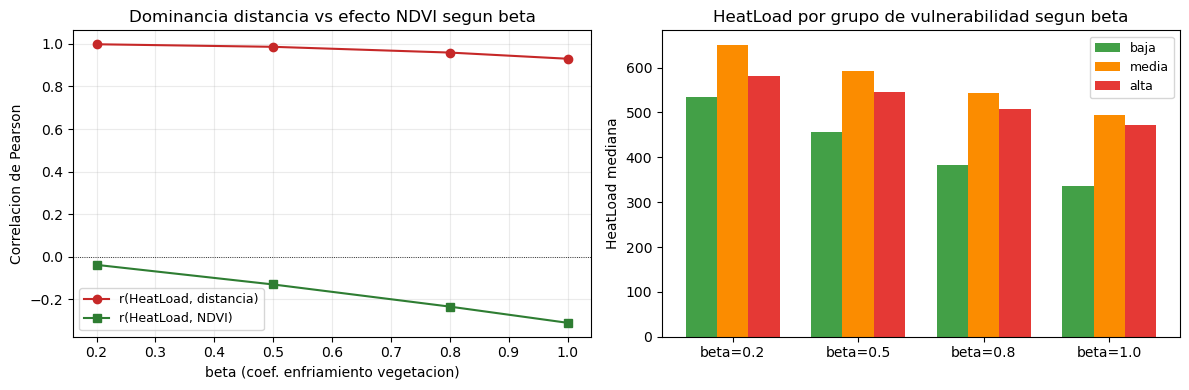

Conclusion de robustez:
 - r(HeatLoad, distancia) >= 0.93 en todo el rango -> distancia siempre domina.
 - estatico sobreestima en 80-93% de los casos.
 - alta > baja se mantiene en todos los beta: True


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(sens['beta'], sens['r_dist'], 'o-', label='r(HeatLoad, distancia)', color='#C62828')
ax[0].plot(sens['beta'], sens['r_ndvi'], 's-', label='r(HeatLoad, NDVI)', color='#2E7D32')
ax[0].axhline(0, color='k', lw=0.6, ls=':')
ax[0].set_xlabel('beta (coef. enfriamiento vegetacion)')
ax[0].set_ylabel('Correlacion de Pearson')
ax[0].set_title('Dominancia distancia vs efecto NDVI segun beta')
ax[0].legend(fontsize=9); ax[0].grid(alpha=0.25)

w = 0.25; x = np.arange(len(sens))
ax[1].bar(x - w, sens['med_baja'],  w, label='baja',  color='#43A047')
ax[1].bar(x,     sens['med_media'], w, label='media', color='#FB8C00')
ax[1].bar(x + w, sens['med_alta'],  w, label='alta',  color='#E53935')
ax[1].set_xticks(x); ax[1].set_xticklabels(['beta=%.1f' % b for b in sens['beta']])
ax[1].set_ylabel('HeatLoad mediana')
ax[1].set_title('HeatLoad por grupo de vulnerabilidad segun beta')
ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

print('Conclusion de robustez:')
print(' - r(HeatLoad, distancia) >= %.2f en todo el rango -> distancia siempre domina.' % sens['r_dist'].min())
print(' - estatico sobreestima en %.0f-%.0f%% de los casos.' % (sens['static_overest_%'].min(), sens['static_overest_%'].max()))
print(' - alta > baja se mantiene en todos los beta: %s' % bool(sens['alta_gt_baja'].all()))


## Parte 3 - Material complementario (cosechado de 5.abm_run, sin cambiar el modelo)

### 3a. Requerimientos computacionales (responde R3-1)
Tamano del problema, tiempo de ruteo (NetworkX vs igraph) y proyeccion a Gran Santiago.

In [12]:
import time
import igraph as ig

# Tamano del problema
n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
n_ag    = len(agents_salud)
print('Red peatonal: %d nodos, %d aristas' % (n_nodes, n_edges))
print('Agentes ruteados: %d' % n_ag)

# Construir grafo igraph (deduplicando aristas por menor longitud)
t0 = time.perf_counter()
nodes_list  = list(G.nodes())
node_to_idx = {n: i for i, n in enumerate(nodes_list)}
edict = {}
for u, v, d in G.edges(data=True):
    k = (node_to_idx[u], node_to_idx[v]); l = float(d.get('length', 1.0))
    if k not in edict or l < edict[k]:
        edict[k] = l
ig_G = ig.Graph(n=len(nodes_list), edges=list(edict.keys()), directed=True)
ig_G.es['length'] = list(edict.values())
t_build = time.perf_counter() - t0

# NetworkX timing
t0 = time.perf_counter()
for _, r in agents_salud.iterrows():
    try:
        nx.path_weight(G, nx.shortest_path(G, r['origin_node'], r['dest_node'], weight='length'), weight='length')
    except Exception:
        pass
t_nx = time.perf_counter() - t0

# igraph timing
t0 = time.perf_counter()
for _, r in agents_salud.iterrows():
    try:
        src, tgt = node_to_idx[r['origin_node']], node_to_idx[r['dest_node']]
        ep = ig_G.get_shortest_paths(src, tgt, weights='length', output='epath')[0]
    except Exception:
        pass
t_ig = time.perf_counter() - t0

print('\nRuteo %d agentes:' % n_ag)
print('  NetworkX: %.2f s' % t_nx)
print('  igraph:   %.2f s  (build grafo: %.2f s)' % (t_ig, t_build))
print('  speedup:  %.1fx' % (t_nx / t_ig))

# Proyeccion Gran Santiago (~500k adultos mayores / 10 = 50k agentes)
factor_gs = 50_000 / n_ag
print('\nProyeccion Gran Santiago (~%.0fx agentes, escalado lineal):' % factor_gs)
print('  ruteo igraph estimado: %.0f s (%.1f min)' % (t_ig * factor_gs, t_ig * factor_gs / 60))


Red peatonal: 12535 nodos, 36488 aristas
Agentes ruteados: 1306

Ruteo 1306 agentes:
  NetworkX: 1.02 s
  igraph:   0.88 s  (build grafo: 0.18 s)
  speedup:  1.2x

Proyeccion Gran Santiago (~38x agentes, escalado lineal):
  ruteo igraph estimado: 34 s (0.6 min)


### 3b. Formulacion WBGT complementaria (seccion 4.5 - robustness check)

Modelo alternativo del motor ABM de la tesis (`src/simulation.py`): acumula carga termica
en grados-minuto (°C·min) solo cuando el WBGT efectivo supera un umbral ajustado por
vulnerabilidad, con enfriamiento aditivo por NDVI. Se corre sobre las MISMAS trayectorias
de la Parte 1 y un dia representativo de verano. Objetivo: verificar que los hallazgos
estructurales del modelo NDVI principal se sostienen bajo una formulacion fisica distinta.
NO reemplaza el modelo del paper.

In [13]:
import sys
sys.path.insert(0, str(Path('..').resolve()))
from src.simulation import SimConfig, build_agents, run, make_wbgt_profile

cfg = SimConfig()

# Dia representativo de OLA DE CALOR severa (apropiado para un paper de heatwaves)
wbgt_profile = make_wbgt_profile(T_max=36.0, HR_min=20.0, Rs_max=1000.0, config=cfg)
print('Perfil WBGT: min=%.1f max=%.1f C  |  umbral base=%.1f C  alpha NDVI=%.1f C'
      % (wbgt_profile.min(), wbgt_profile.max(), cfg.wbgt_umbral_base, cfg.ndvi_alpha))

# Construir walkers minimos para el ABM desde las trayectorias de la Parte 1
walkers_wbgt = results_walk[['agent_id', 'vuln_group', 'route_length_m', 'ndvi_route']].copy()
walkers_wbgt['purpose_group_model'] = 'salud'

agents_wbgt = build_agents(walkers_wbgt, ndvi_min=ndvi_min, ndvi_max=ndvi_max, config=cfg, seed=SEED)
final_wbgt, _ = run(agents_wbgt, wbgt_profile=wbgt_profile, config=cfg, snapshot_every=10_000)

activos = final_wbgt[final_wbgt['status'] != 'en_casa'].copy()
print('\nAgentes activos: %d' % len(activos))


Perfil WBGT: min=26.2 max=30.3 C  |  umbral base=27.0 C  alpha NDVI=2.5 C

Agentes activos: 1125


In [14]:
# Hallazgos estructurales bajo WBGT
r_dist_w = activos[['heat_load', 'route_length_m']].corr().iloc[0, 1]
r_ndvi_w = activos[['heat_load', 'ndvi_route']].corr().iloc[0, 1]
print('Modelo WBGT (heat_load en C-min):')
print('  r(heat, distancia) = %.3f' % r_dist_w)
print('  r(heat, NDVI ruta) = %.3f' % r_ndvi_w)
print('\n  mediana heat_load por grupo:')
print(activos.groupby('vuln_group')['heat_load'].median().round(1))

# Acuerdo de ranking entre modelo NDVI (paper) y modelo WBGT
from scipy.stats import spearmanr
cmp = activos[['agent_id', 'heat_load']].rename(columns={'heat_load': 'wbgt'}).merge(
    results_walk[['agent_id', 'heat_load']].rename(columns={'heat_load': 'ndvi'}), on='agent_id')
rho, _ = spearmanr(cmp['ndvi'], cmp['wbgt'])
print('\nAcuerdo de ranking NDVI vs WBGT (Spearman rho) = %.3f' % rho)


Modelo WBGT (heat_load en C-min):
  r(heat, distancia) = 0.686
  r(heat, NDVI ruta) = -0.341

  mediana heat_load por grupo:
vuln_group
alta     118.2
baja      19.9
media     72.7
Name: heat_load, dtype: float64

Acuerdo de ranking NDVI vs WBGT (Spearman rho) = 0.764


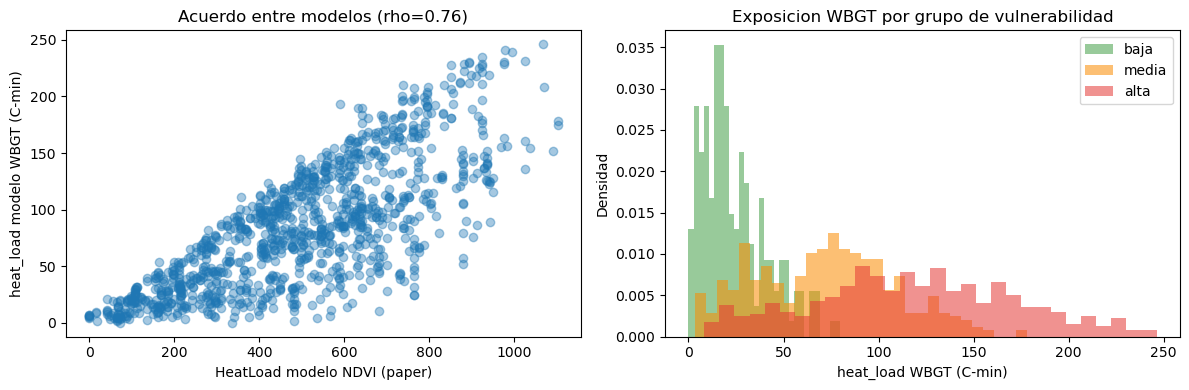

Robustez: bajo el modelo WBGT, la distancia sigue dominando (r=0.69),
el NDVI sigue siendo moderador negativo (r=-0.34),
y el ranking de agentes coincide fuertemente con el modelo NDVI (rho=0.76).


In [15]:
# Comparacion visual NDVI vs WBGT
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(cmp['ndvi'], cmp['wbgt'], alpha=0.4)
ax[0].set_xlabel('HeatLoad modelo NDVI (paper)')
ax[0].set_ylabel('heat_load modelo WBGT (C-min)')
ax[0].set_title('Acuerdo entre modelos (rho=%.2f)' % rho)

for vg, c in [('baja', '#43A047'), ('media', '#FB8C00'), ('alta', '#E53935')]:
    sub = activos[activos['vuln_group'] == vg]['heat_load']
    ax[1].hist(sub, bins=30, alpha=0.55, label=vg, color=c, density=True)
ax[1].set_xlabel('heat_load WBGT (C-min)')
ax[1].set_ylabel('Densidad')
ax[1].set_title('Exposicion WBGT por grupo de vulnerabilidad')
ax[1].legend()
plt.tight_layout(); plt.show()

print('Robustez: bajo el modelo WBGT, la distancia sigue dominando (r=%.2f),' % r_dist_w)
print('el NDVI sigue siendo moderador negativo (r=%.2f),' % r_ndvi_w)
print('y el ranking de agentes coincide fuertemente con el modelo NDVI (rho=%.2f).' % rho)


## Exportacion de figuras para el paper (tex/, 300 dpi)

Regenera las figuras que dependen de la corrida reproducible y crea las dos nuevas
de la seccion 4.5. Las figuras conceptuales (model_overview) y de mapas/NDVI-vuln a
nivel manzana no cambian y se conservan.

In [16]:
TEXDIR = Path('../tex')
TEXDIR.mkdir(exist_ok=True)
plt.rcParams.update({'font.size': 11, 'savefig.dpi': 300, 'savefig.bbox': 'tight'})

# --- scatter_static_dynamic.png : FIGURA COMBINADA (2 paneles) -> fusiona Fig 4 y Fig 5 ---
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8), layout='constrained')
ax[0].scatter(results_walk['static_exposure'], results_walk['dynamic_exposure'], alpha=0.4, s=14)
ax[0].plot([0, 1], [0, 1], 'k--', lw=0.8)
ax[0].set_xlabel('Static (residential) exposure')
ax[0].set_ylabel('Dynamic (trajectory-based) exposure')
ax[0].set_title('Static vs dynamic exposure', fontsize=10)
ax[1].hist(results_walk['delta_exp'], bins=35, color='#5B8DB8', edgecolor='white')
ax[1].axvline(0, color='k', lw=1.0, ls='--')
ax[1].set_xlabel('Dynamic minus static exposure')
ax[1].set_ylabel('Number of trajectories')
ax[1].set_title('Distribution of differences', fontsize=10)
fig.savefig(TEXDIR / 'scatter_static_dynamic.png'); plt.close(fig)

# --- inequality_boxplot.png ---
fig, ax = plt.subplots(figsize=(5, 4))
order = ['baja', 'media', 'alta']
data = [results_walk.loc[results_walk['vuln_group'] == g, 'heat_load'].values for g in order]
bp = ax.boxplot(data, labels=['low', 'medium', 'high'], patch_artist=True)
for patch, c in zip(bp['boxes'], ['#43A047', '#FB8C00', '#E53935']):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax.set_xlabel('Vulnerability group'); ax.set_ylabel('Heat load')
fig.savefig(TEXDIR / 'inequality_boxplot.png'); plt.close(fig)

print('Figura combinada scatter_static_dynamic.png (2 paneles) + inequality_boxplot.png en tex/')


Figura combinada scatter_static_dynamic.png (2 paneles) + inequality_boxplot.png en tex/


In [17]:
# --- sensitivity_beta.png (seccion 4.5) ---
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.plot(sens['beta'], sens['r_dist'], 'o-', color='#C62828', label='r(heat load, distance)')
ax.plot(sens['beta'], sens['r_ndvi'], 's-', color='#2E7D32', label='r(heat load, NDVI)')
ax.axhline(0, color='k', lw=0.6, ls=':')
ax.set_xlabel(r'Cooling coefficient $\beta$')
ax.set_ylabel('Pearson correlation')
ax.legend(fontsize=9); ax.grid(alpha=0.25)
fig.savefig(TEXDIR / 'sensitivity_beta.png'); plt.close(fig)

# --- wbgt_comparison.png (seccion 4.5) -- constrained_layout evita solape de ejes ---
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8), layout='constrained')
ax[0].scatter(cmp['ndvi'], cmp['wbgt'], alpha=0.4, s=14)
ax[0].set_xlabel('Heat load (NDVI model)')
ax[0].set_ylabel(r'Heat load (WBGT, $^\circ$C$\cdot$min)')
ax[0].set_title(r'Model agreement ($\rho$ = %.2f)' % rho, fontsize=10)
for vg, c, lab in [('baja', '#43A047', 'low'), ('media', '#FB8C00', 'medium'), ('alta', '#E53935', 'high')]:
    sub = activos[activos['vuln_group'] == vg]['heat_load']
    ax[1].hist(sub, bins=30, alpha=0.55, label=lab, color=c, density=True)
ax[1].set_xlabel(r'Heat load (WBGT, $^\circ$C$\cdot$min)')
ax[1].set_ylabel('Density'); ax[1].set_title('WBGT exposure by group', fontsize=10)
ax[1].legend(fontsize=9)
fig.savefig(TEXDIR / 'wbgt_comparison.png'); plt.close(fig)

print('Figuras de la seccion 4.5 creadas en tex/')
import os
print('Contenido tex/:', sorted(f for f in os.listdir(TEXDIR) if f.endswith('.png')))


Figuras de la seccion 4.5 creadas en tex/
Contenido tex/: ['delta_boxplot.png', 'inequality_boxplot.png', 'scatter_static_dynamic.png', 'sensitivity_beta.png', 'wbgt_comparison.png']
